In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

**Lorenz-63**

In [2]:
from da_models.lorenz63 import rhs

In [3]:
# Starting point
x0 = [1.0, 1.0, 1.0]

t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)

sol = solve_ivp(rhs, t_span, x0, t_eval=t_eval, args=(10.0, 28.0, 8/3), rtol=1e-9, atol=1e-9)

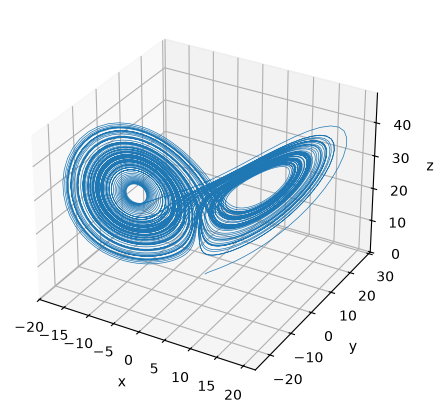

In [4]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.show()

In [5]:
import os
os.makedirs("../data", exist_ok=True)

final_state = sol.y[:, -1]
np.save("../data/lorenz63_ic.npy", final_state)
print(final_state)

[ 2.49960256  2.55741113 19.74661021]


**One-layer Lorenz-96**

In [6]:
from da_models.lorenz96 import rhs as rhs_l96

In [7]:
K = 40
u0 = np.full(K, 8.0)
u0[0] += 0.01

t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)

sol96 = solve_ivp(rhs_l96, t_span, u0, t_eval=t_eval, args=(8.0, 1.0), rtol=1e-9, atol=1e-9)

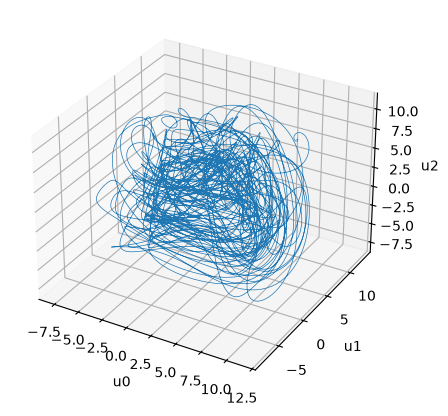

In [8]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(sol96.y[0], sol96.y[1], sol96.y[2], lw=0.5)
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
plt.show()

In [9]:
final_state_l96 = sol96.y[:, -1]
np.save("../data/lorenz96_ic.npy", final_state_l96)
print(final_state_l96)

[ 4.66160401  5.73522194  2.4450368  -5.49930523  0.01879502  4.84637371
  7.99289536  2.82764591  5.98242882  7.27137156 -0.09438529  3.23375468
  0.72373064 -1.34685692  2.05953551  5.64375133  5.76883766  2.31713186
 -2.75765522 -0.72866924 -0.01051097  0.48523387  6.31731589  1.27231047
 -4.68460008  3.66716149  2.07042727  1.46206201  6.55530609  5.36743466
 -6.67585953  1.9143056   3.09720412  8.50726357  5.62452609 -1.18250315
 -1.15669241 -2.00673095  3.57873149  8.49639184]


**Two-layer Lorenz-96**

In [10]:
from da_models.lorenz96 import rhs_two_layer, pack_two_layer, unpack_two_layer

In [11]:
K, J = 40, 5
u0 = np.full(K, 8.0)
u0[0] += 0.01
v0 = np.zeros((K, J))
state0 = pack_two_layer(u0, v0)

t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)

sol96_2L = solve_ivp(
    rhs_two_layer, t_span, state0, t_eval=t_eval,
    args=(K, J, 8.0, 1.0, 0.05, (0.2, 0.5, 1.0, 2.0, 5.0)),
    rtol=1e-9, atol=1e-9,
)

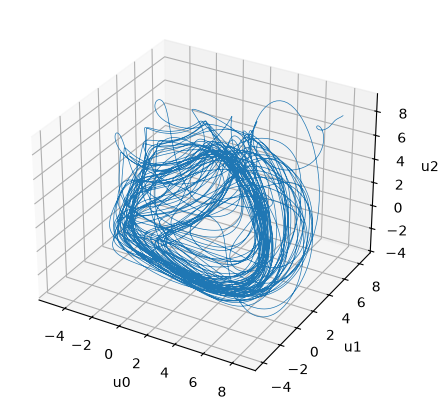

In [12]:
u_traj = sol96_2L.y[:K]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(u_traj[0], u_traj[1], u_traj[2], lw=0.5)
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
plt.show()

In [13]:
final_state_l96_2L = sol96_2L.y[:, -1]
np.save("../data/lorenz96_two_layer_ic.npy", final_state_l96_2L)
print(final_state_l96_2L.shape)

(240,)


**Sturis**

In [14]:
from da_models.sturis import rhs as rhs_sturis

In [15]:
state0_sturis = [36.0, 44.0, 11000.0, 0.0, 0.0, 0.0]  # [Ip, Ii, G, h1, h2, h3]

t_span = (0, 1000)
t_eval = np.linspace(*t_span, 1000)

sol_sturis = solve_ivp(rhs_sturis, t_span, state0_sturis, t_eval=t_eval, rtol=1e-9, atol=1e-9)

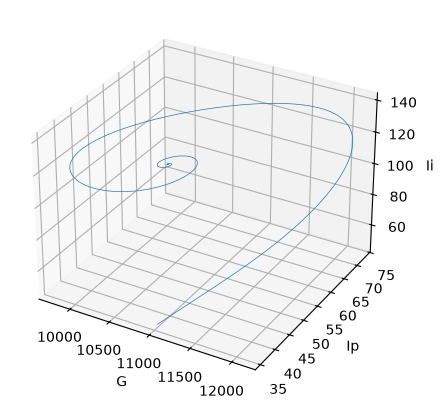

In [16]:
G, Ip, Ii = sol_sturis.y[2], sol_sturis.y[0], sol_sturis.y[1]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(G, Ip, Ii, lw=0.5)
ax.set_xlabel('G'); ax.set_ylabel('Ip'); ax.set_zlabel('Ii')
plt.show()

In [17]:
final_state_sturis = sol_sturis.y[:, -1]
np.save("../data/sturis_ic.npy", final_state_sturis)
print(final_state_sturis)

[   49.36583793   116.77968236 10631.64949338    49.36600702
    49.36611248    49.36612651]


**Goodwin-Keen**

In [18]:
from da_models.goodwin_keen import rhs as rhs_gk


In [19]:
state0_gk = [0.8, 0.9, 0.1]

t_span = (0, 500)
t_eval = np.linspace(*t_span, 10000)

sol_gk = solve_ivp(rhs_gk, t_span, state0_gk, t_eval=t_eval, rtol=1e-9, atol=1e-9)

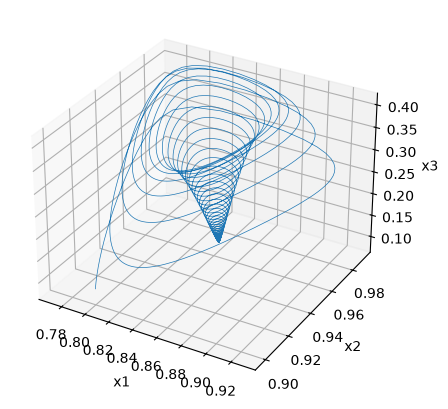

In [20]:
x1, x2, x3 = sol_gk.y[0], sol_gk.y[1], sol_gk.y[2]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(x1, x2, x3, lw=0.5)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
plt.show()

In [21]:
final_state_gk = sol_gk.y[:, -1]
np.save("../data/goodwin_keen_ic.npy", final_state_gk)
print(final_state_gk)

[0.83605283 0.96861175 0.07019112]
